<a href="https://colab.research.google.com/github/motor17/motor17/blob/main/Numerical_Analysis_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

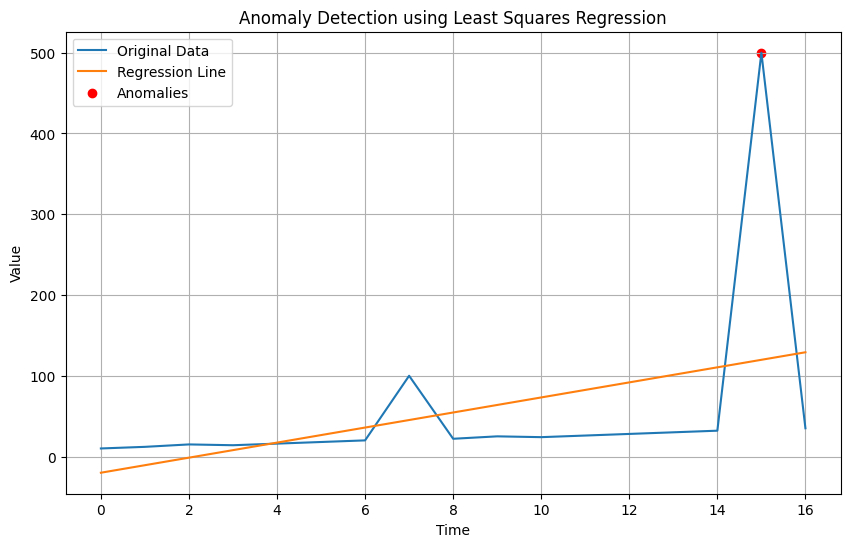

Anomaly indices: [15]


In [ ]:


import numpy as np
import matplotlib.pyplot as plt

def find_anomalies(data, threshold=3):
    """
    Finds anomalies in a time series using least squares regression and a threshold.

    Args:
        data: A 1D numpy array representing the time series data.
        threshold: The number of standard deviations from the regression line
                   to consider a point an anomaly.

    Returns:
        A tuple containing:
            - anomalies: A 1D numpy array of indices of the anomaly points.
            - regression_line: A 1D numpy array representing the least squares regression line.
    """
    x = np.arange(len(data))
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, data, rcond=None)[0]  # Least squares regression

    regression_line = m * x + c
    residuals = data - regression_line
    std_dev = np.std(residuals)

    anomalies = np.where(np.abs(residuals) > threshold * std_dev)[0]

    return anomalies, regression_line


# Example usage
# Sample time series data with anomalies
data = np.array([10, 12, 15, 14, 16, 18, 20, 100, 22, 25, 24, 26, 28, 30, 32, 500, 35])

anomalies, regression_line = find_anomalies(data, threshold=2)


# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(data, label="Original Data")
plt.plot(regression_line, label="Regression Line")
plt.scatter(anomalies, data[anomalies], color='red', label="Anomalies")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Anomaly Detection using Least Squares Regression")
plt.legend()
plt.grid(True)
plt.show()


print("Anomaly indices:", anomalies)

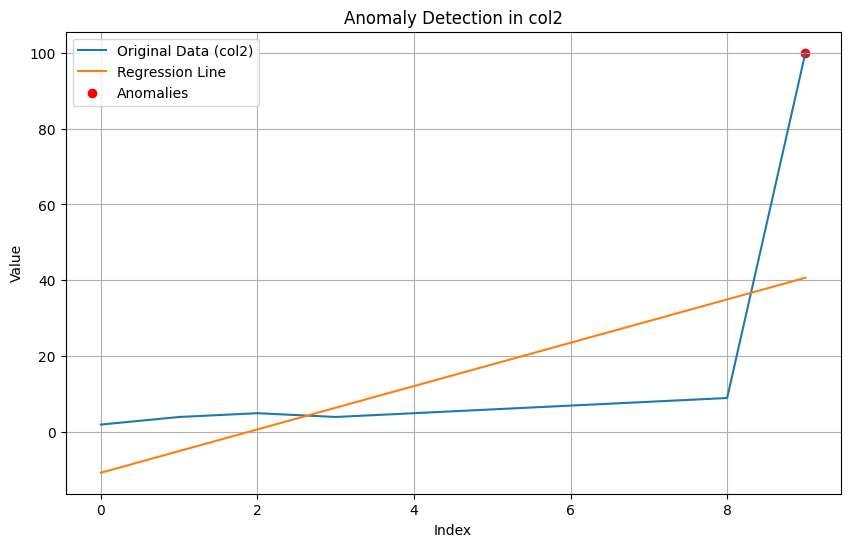

Anomaly indices in col2: [9]


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Assuming col1 and col2 are already defined as lists
# Example:
col1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
col2 = [2, 4, 5, 4, 5, 6, 7, 8, 9, 100]


def find_anomalies(data, threshold=3):
    """
    Finds anomalies in a time series using least squares regression and a threshold.
    """
    x = np.arange(len(data))
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, data, rcond=None)[0]

    regression_line = m * x + c
    residuals = data - regression_line
    std_dev = np.std(residuals)

    anomalies = np.where(np.abs(residuals) > threshold * std_dev)[0]

    return anomalies, regression_line


# Create a Pandas DataFrame
df = pd.DataFrame({'col1': col1, 'col2': col2})

# Apply the anomaly detection function to 'col2'
anomalies, regression_line = find_anomalies(df['col2'], threshold=2)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(df['col2'], label="Original Data (col2)")
plt.plot(regression_line, label="Regression Line")
plt.scatter(anomalies, df['col2'][anomalies], color='red', label="Anomalies")

plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Anomaly Detection in col2")
plt.legend()
plt.grid(True)
plt.show()

print("Anomaly indices in col2:", anomalies)

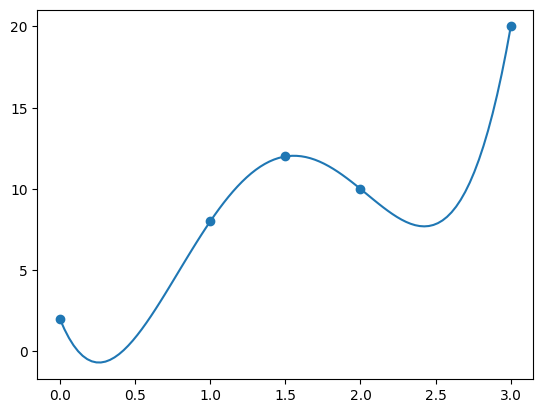

In [ ]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt
!pip install seaborn

X = np.array([0, 1, 1.5, 2, 3])
Y = np.array([2, 8, 12, 10, 20])

n = len(X)
poly = Polynomial(np.zeros(n))

for j in range(n):
  k = [k for k in range(n) if k != j]
  roots = -1 * X[k]

  sub_poly = Polynomial.fromroots(X[k])
  scale = Y[j] / np.prod(X[j] - X[k])
  sub_poly.coef *= scale

  poly.coef += sub_poly.coef


plt.scatter(X, Y)
Xinterp = np.linspace(min(X), max(X), 100)
plt.plot(Xinterp, poly(Xinterp))
plt.show()

In [ ]:
#Least Squares Regression
#Given a set of individual data points and dependent data points, we would like to find an estimation function that describes the data as well as possible
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
!pip install seaborn


plt.style.use('seaborn-poster')
# generate x and y
x = np.linspace(0, 1, 101)
y = 1 + x + x * np.random.random(len(x))
# assemble matrix A
A = np.vstack([x, np.ones(len(x))]).T

# turn y into a column vector
y = y[:, np.newaxis]
# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T,A)),A.T)),y)
print(alpha)
# plot the results
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, alpha[0]*x + alpha[1], 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

[[1.46858079]
 [0.99862765]]


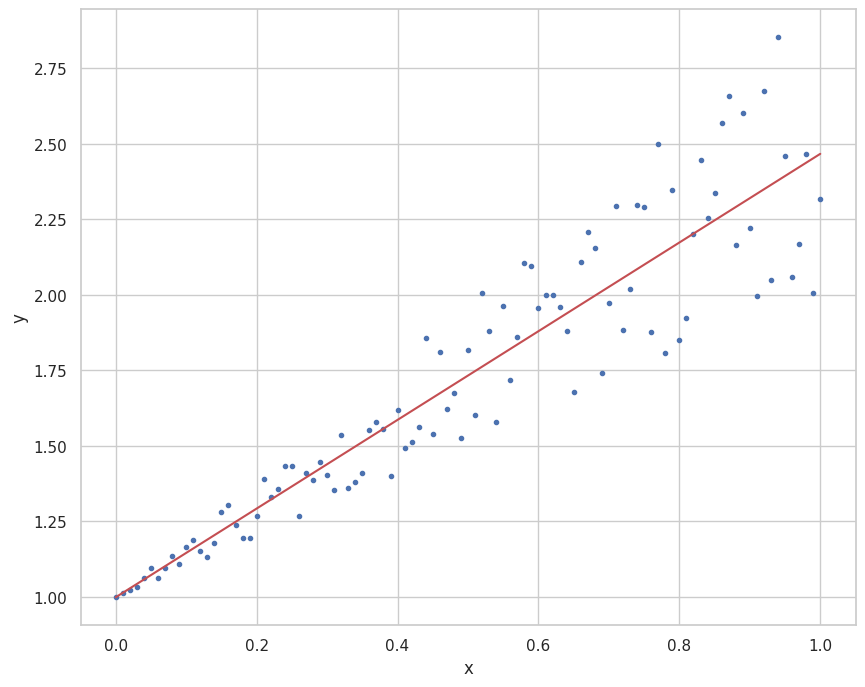

In [ ]:
#Least Squares Regression
#Given a set of individual data points and dependent data points, we would like to find an estimation function that describes the data as well as possible
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns # Import seaborn


#plt.style.use('seaborn-poster') # This is replaced by the line below
sns.set_theme(style="whitegrid") # Set the Seaborn theme instead

# generate x and y
x = np.linspace(0, 1, 101)
y = 1 + x + x * np.random.random(len(x))
# assemble matrix A
A = np.vstack([x, np.ones(len(x))]).T

# turn y into a column vector
y = y[:, np.newaxis]
# Direct least square regression
alpha = np.dot((np.dot(np.linalg.inv(np.dot(A.T,A)),A.T)),y)
print(alpha)
# plot the results
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, alpha[0]*x + alpha[1], 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
#use optimize.curve_fit from scipy
#generate x and y
x = np.linspace(0, 1, 101)
y = 1 + x + x * np.random.random(len(x))
def func(x, a, b):
    y = a*x + b
    return y

alpha = optimize.curve_fit(func, xdata = x, ydata = y)[0]
print(alpha)

[1.54501958 1.01220337]


# **least squares regression for nonlinear functions**

In [ ]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt

plt.style.use('seaborn-poster')
# let's generate x and y, and add some noise into y
x = np.linspace(0, 10, 101)
y = 0.1*np.exp(0.3*x) + 0.1*np.random.random(len(x))
# Let's have a look of the data
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

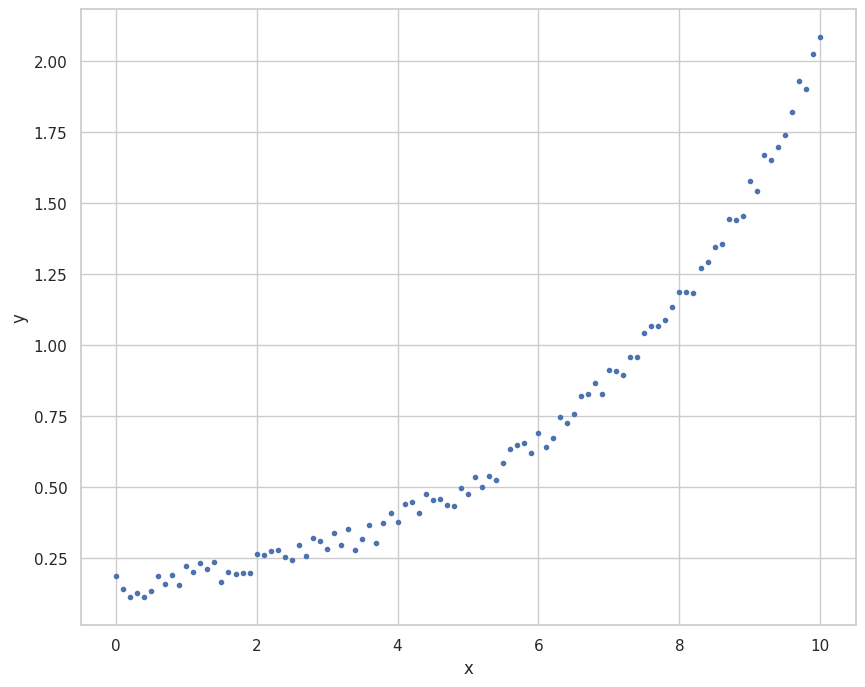

alpha=0.13445002002911408, beta=0.2692788213401716


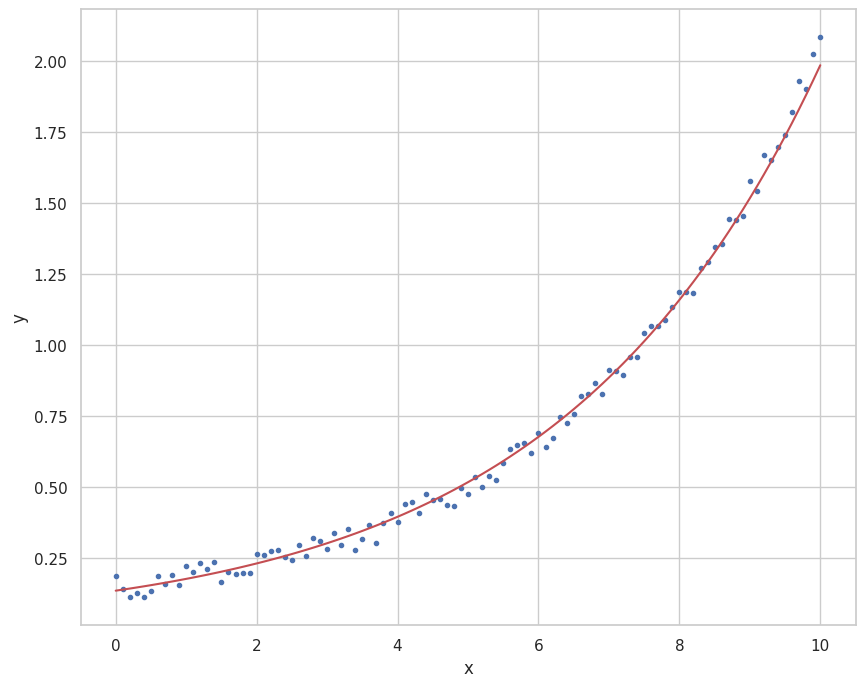

In [ ]:
import numpy as np
from scipy import optimize
import matplotlib.pyplot as plt
import seaborn as sns # Make sure seaborn is imported

#plt.style.use('seaborn-poster') # Remove this line - causing the error
sns.set_theme(style="whitegrid") # Use this to set a Seaborn theme

# let's generate x and y, and add some noise into y
x = np.linspace(0, 10, 101)
y = 0.1*np.exp(0.3*x) + 0.1*np.random.random(len(x))
# Let's have a look of the data
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.xlabel('x')
plt.ylabel('y')
plt.show()
A = np.vstack([x, np.ones(len(x))]).T
beta, log_alpha = np.linalg.lstsq(A, np.log(y), rcond = None)[0]
alpha = np.exp(log_alpha)
print(f'alpha={alpha}, beta={beta}')
# Let's have a look of the data
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, alpha*np.exp(beta*x), 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

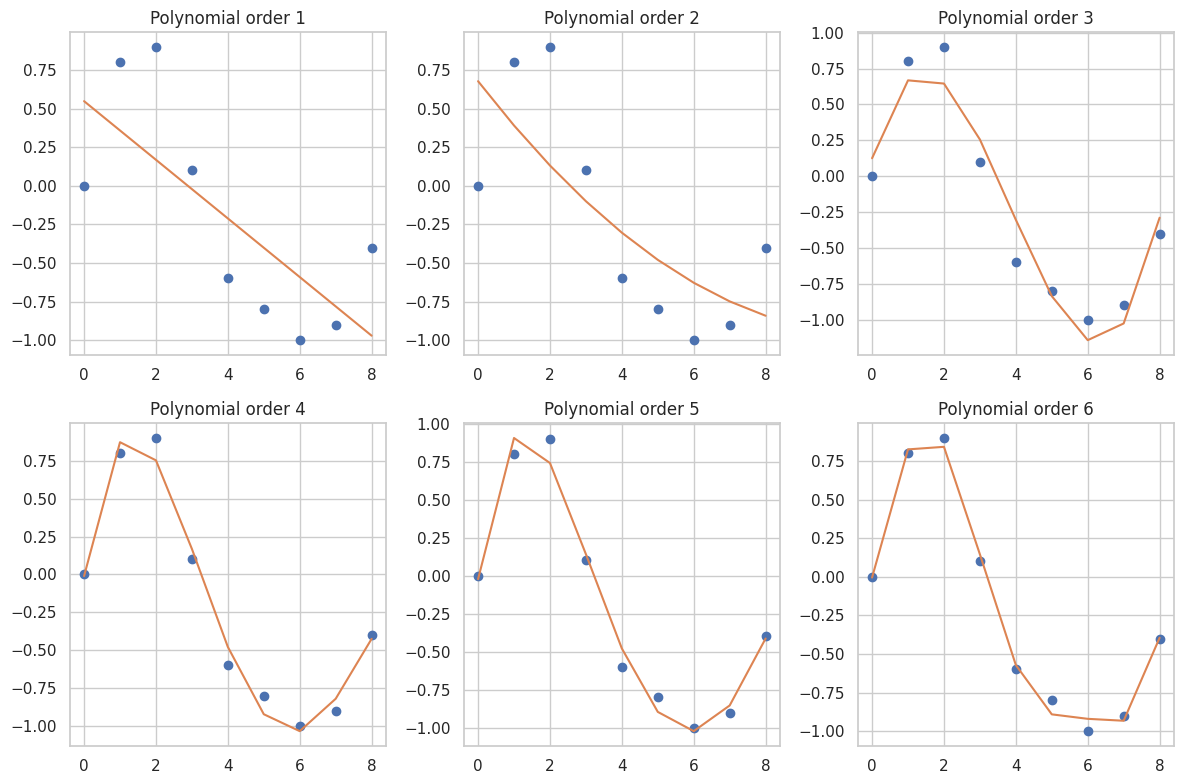

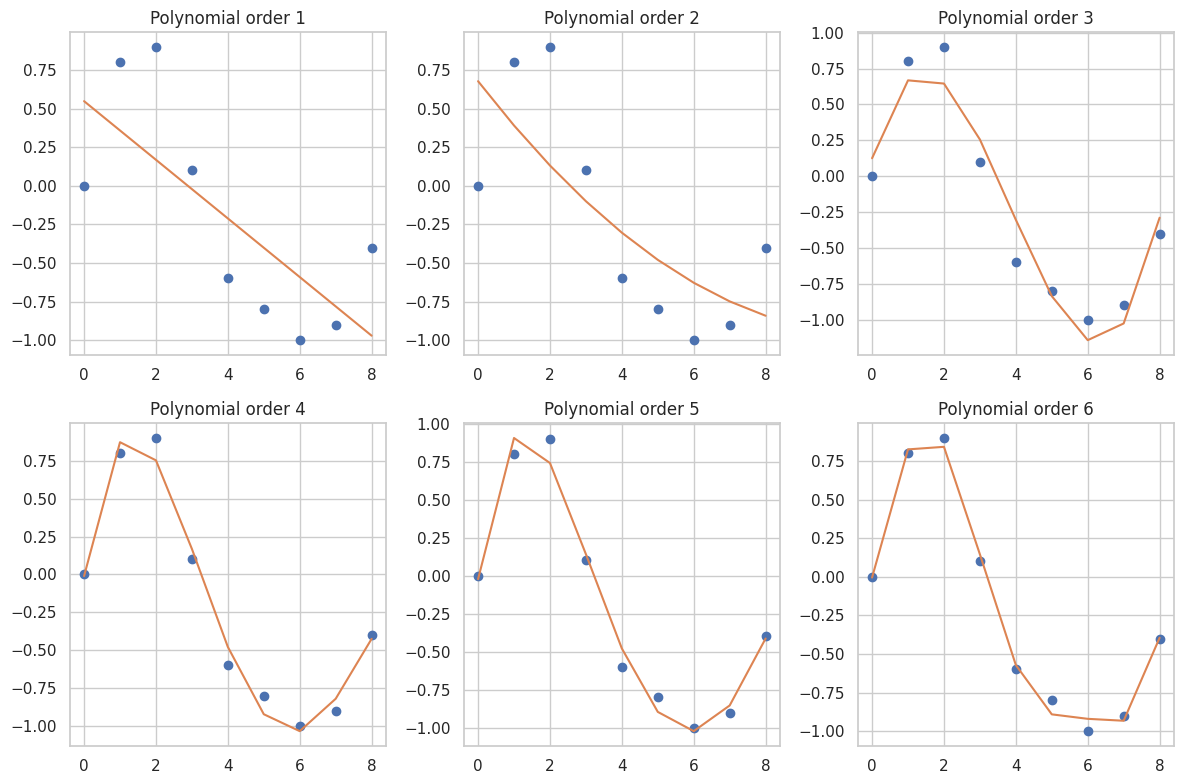

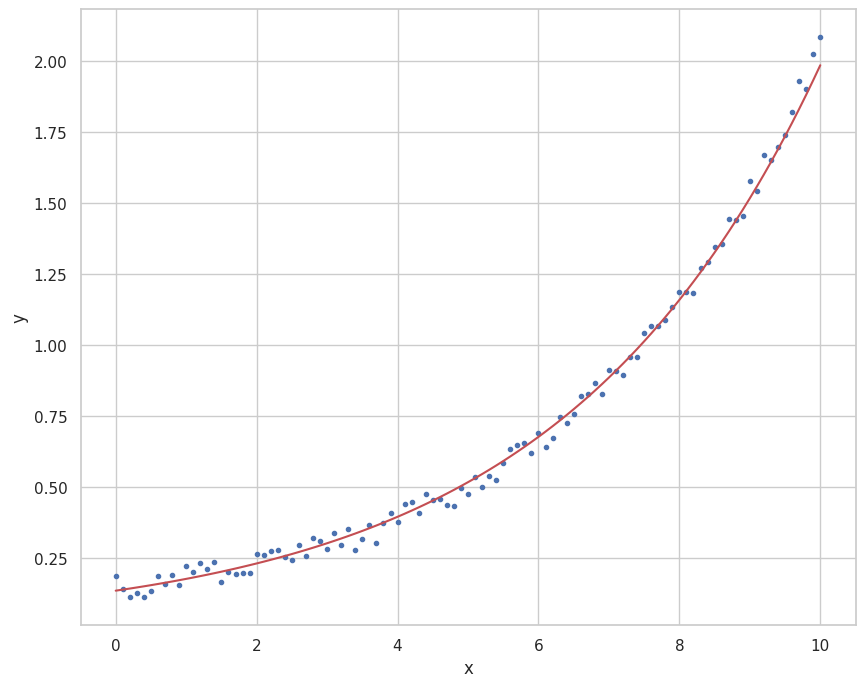

In [ ]:
#polynomial regression
x_d = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
y_d = np.array([0, 0.8, 0.9, 0.1, -0.6, -0.8, -1, -0.9, -0.4])

plt.figure(figsize = (12, 8))
for i in range(1, 7):

    # get the polynomial coefficients
    y_est = np.polyfit(x_d, y_d, i)
    plt.subplot(2,3,i)
    plt.plot(x_d, y_d, 'o')
    # evaluate the values for a polynomial
    plt.plot(x_d, np.polyval(y_est, x_d))
    plt.title(f'Polynomial order {i}')

plt.tight_layout()
plt.show()
x_d = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])
y_d = np.array([0, 0.8, 0.9, 0.1, -0.6, -0.8, -1, -0.9, -0.4])

plt.figure(figsize = (12, 8))
for i in range(1, 7):

    # get the polynomial coefficients
    y_est = np.polyfit(x_d, y_d, i)
    plt.subplot(2,3,i)
    plt.plot(x_d, y_d, 'o')
    # evaluate the values for a polynomial
    plt.plot(x_d, np.polyval(y_est, x_d))
    plt.title(f'Polynomial order {i}')

plt.tight_layout()
plt.show()
# Let's have a look of the data
plt.figure(figsize = (10,8))
plt.plot(x, y, 'b.')
plt.plot(x, alpha*np.exp(beta*x), 'r')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

***LINEAR INTERPOLATION***

2.5


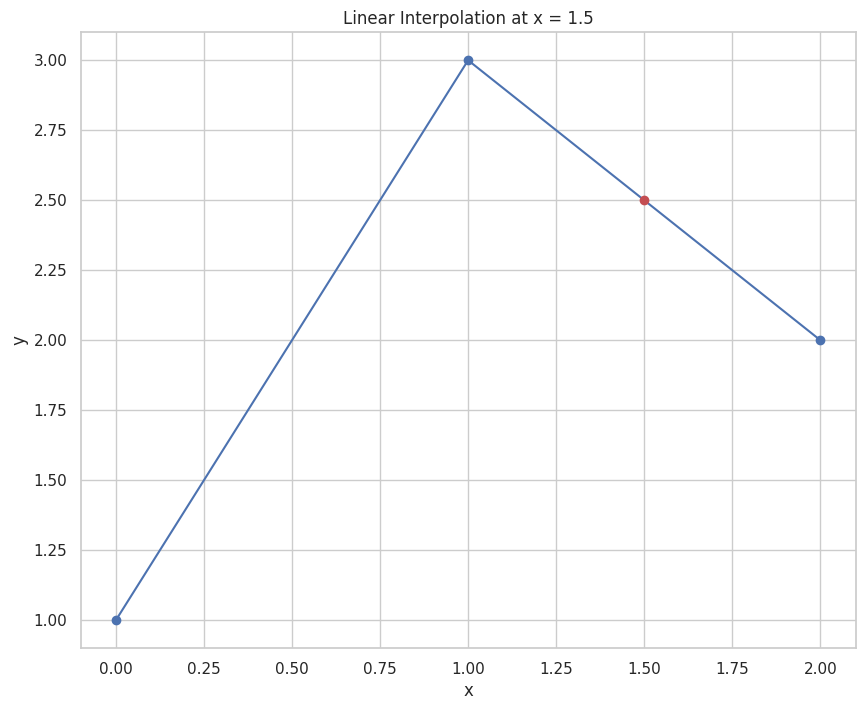

In [ ]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

# Use Seaborn to set the theme, which will affect Matplotlib plots as well
sns.set_theme(style="whitegrid")  # Choose a Seaborn theme, e.g., 'whitegrid', 'darkgrid', etc.


x = [0, 1, 2]
y = [1, 3, 2]

f = interp1d(x, y)
y_hat = f(1.5)
print(y_hat)
plt.figure(figsize = (10,8))
plt.plot(x, y, '-ob')
plt.plot(1.5, y_hat, 'ro')
plt.title('Linear Interpolation at x = 1.5')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Cubic Spline Interpolation

In [ ]:
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-poster')
from scipy.interpolate import CubicSpline
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-poster')
plt.figure(figsize = (10,8))
plt.plot(x_new, y_new, 'b')
plt.plot(x, y, 'ro')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import seaborn as sns  # Import Seaborn

# Instead of using plt.style.use('seaborn-poster'), use Seaborn's set_theme
sns.set_theme(style="whitegrid")

# Now, any Matplotlib plots created after this will use the Seaborn style

# Assuming x, y, x_new, and y_new are defined
# If they're not, make sure to define them appropriately based on your data and interpolation method

plt.figure(figsize=(10, 8))
plt.plot(x_new, y_new, 'b')  # Assuming x_new and y_new are defined
plt.plot(x, y, 'ro')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

NameError: name 'x_new' is not defined

<Figure size 1000x800 with 0 Axes>

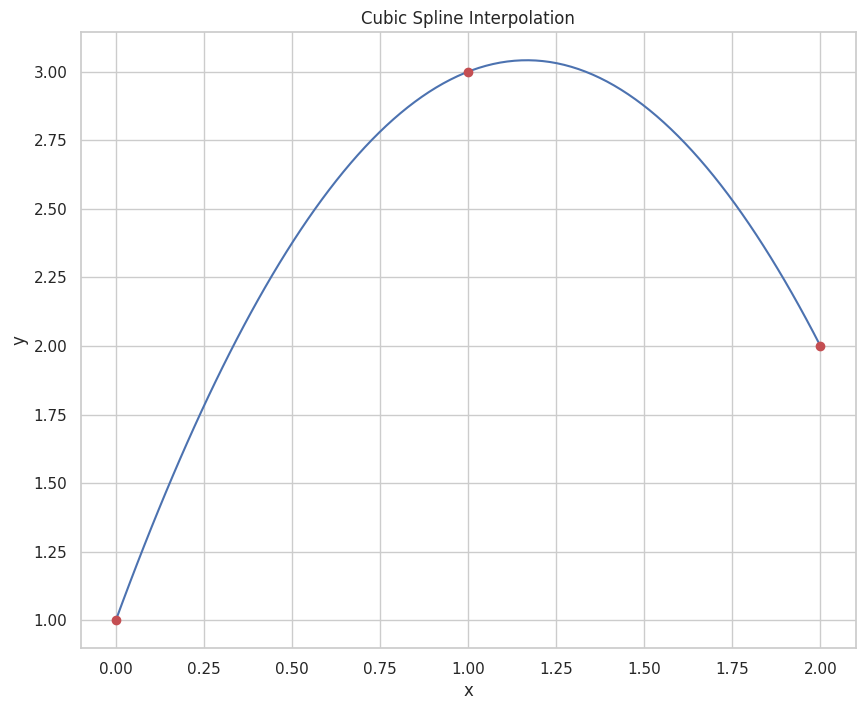

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import seaborn as sns  # Import Seaborn

# Instead of using plt.style.use('seaborn-poster'), use Seaborn's set_theme
sns.set_theme(style="whitegrid")

# Now, any Matplotlib plots created after this will use the Seaborn style

# Assuming x, y, x_new, and y_new are defined
# If they're not, make sure to define them appropriately based on your data and interpolation method
x = [0, 1, 2]
y = [1, 3, 2]

# Define x_new and calculate y_new using CubicSpline
x_new = np.linspace(0, 2, 100)  # Create new x values for interpolation
cs = CubicSpline(x, y)  # Create a CubicSpline object
y_new = cs(x_new)  # Calculate y values for the new x values


plt.figure(figsize=(10, 8))
plt.plot(x_new, y_new, 'b')  # Assuming x_new and y_new are defined
plt.plot(x, y, 'ro')
plt.title('Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

Lagrange Polynomial Interpolation

In [ ]:
import numpy as np
import numpy.polynomial.polynomial as poly
import matplotlib.pyplot as plt

plt.style.use('whitegrid')
x = [0, 1, 2]
y = [1, 3, 2]
P1 = poly.Polynomial(P1_coeff)
P2 = poly.Polynomial(P2_coeff)
P3 = poly.Polynomial(P3_coeff)

x_new = np.arrange(-1.0, 3.1, 0.1)

fig = plt.figure(figsize=(10, 8))
plt.plot(x_new, P1(x_new), 'b', label = 'P1')
plt.plot(x_new, P2(x_new), 'r', label = 'P2')
plt.plot(x_new, P3(x_new), 'g', label = 'P3')

plt.plot(x, np.ones(len(x)), 'ko', x, np.zeros(len(x)), 'ko') #Corrected len(X) to len(x)
plt.title('Lagrange Basis Polynomials')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()

OSError: 'whitegrid' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

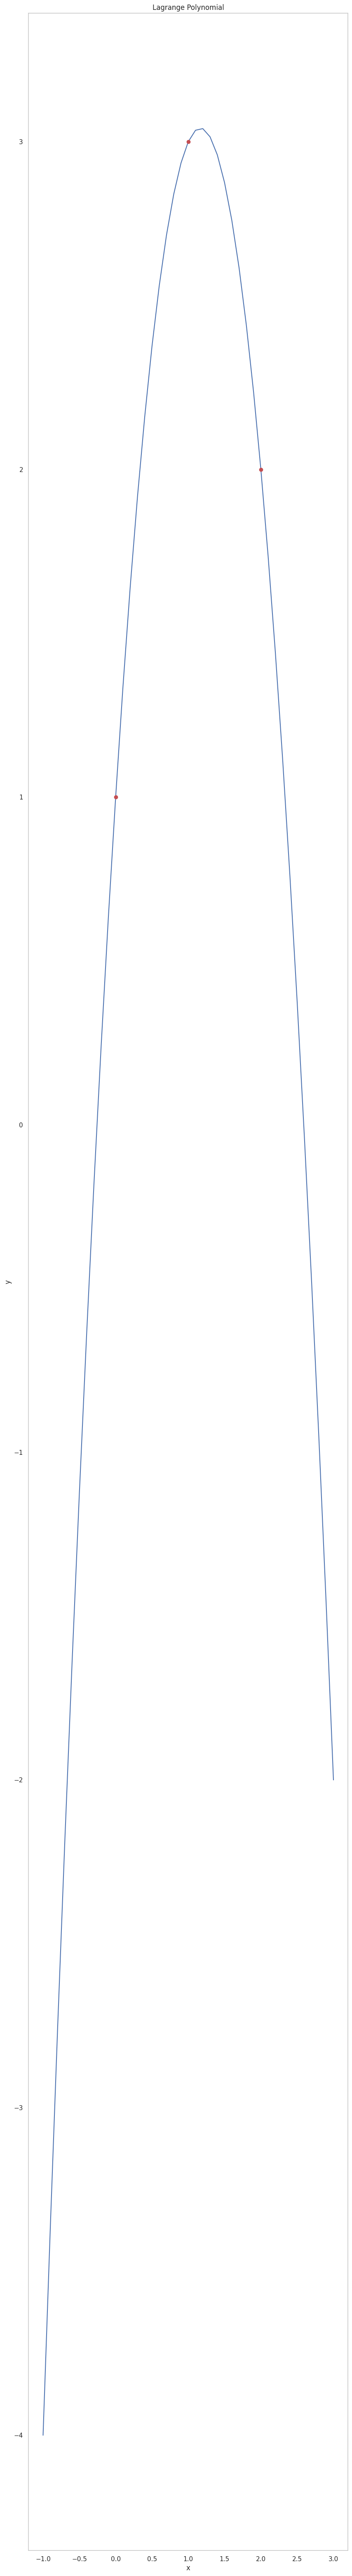

In [ ]:
from scipy.interpolate import lagrange
f = lagrange(x,y)
fig = plt.figure(figsize = (10,80))
plt.plot(x_new, f(x_new), 'b', x, y, 'ro')
plt.title('Lagrange Polynomial')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

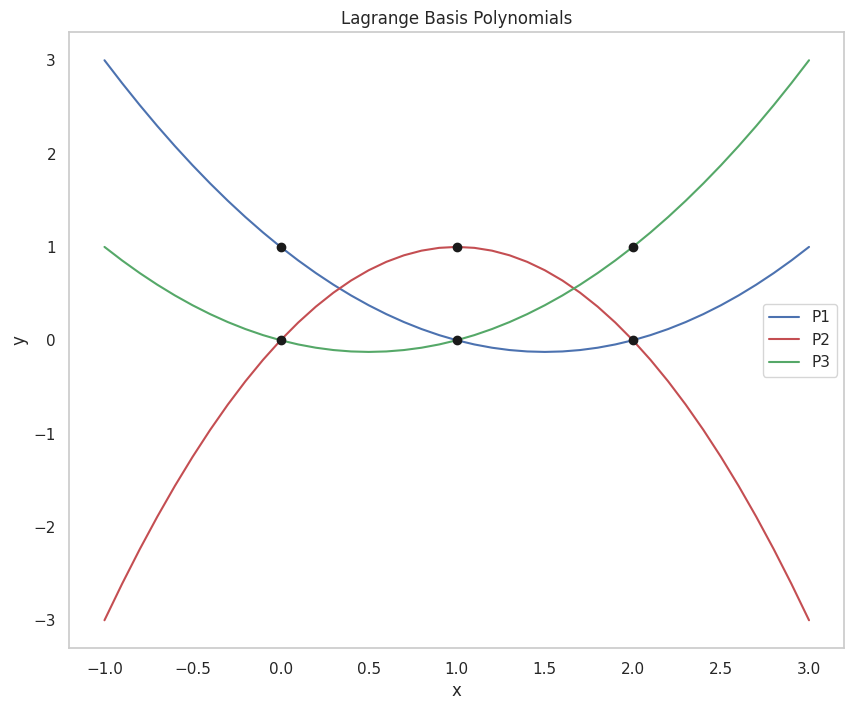

In [ ]:
import numpy as np
import numpy.polynomial.polynomial as poly
import matplotlib.pyplot as plt
import seaborn as sns # Make sure seaborn is imported


sns.set_theme(style="whitegrid") # Use Seaborn's set_theme to apply the style

x = [0, 1, 2]
y = [1, 3, 2]

# Assuming P1_coeff, P2_coeff, P3_coeff are defined somewhere before this
# If they are not defined, you need to define them appropriately based on your Lagrange interpolation logic
# For example:
P1_coeff = [1, -1.5, 0.5]  # Example coefficients for P1
P2_coeff = [0, 2, -1]  # Example coefficients for P2
P3_coeff = [0, -0.5, 0.5]  # Example coefficients for P3

P1 = poly.Polynomial(P1_coeff)
P2 = poly.Polynomial(P2_coeff)
P3 = poly.Polynomial(P3_coeff)

x_new = np.arange(-1.0, 3.1, 0.1)  # Use np.arange instead of np.arrange

fig = plt.figure(figsize=(10, 8))
plt.plot(x_new, P1(x_new), 'b', label='P1')
plt.plot(x_new, P2(x_new), 'r', label='P2')
plt.plot(x_new, P3(x_new), 'g', label='P3')

plt.plot(x, np.ones(len(x)), 'ko', x, np.zeros(len(x)), 'ko')
plt.title('Lagrange Basis Polynomials')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-poster')

%matplotlib inline
def divided_diff(x, y):
    '''
    function to calculate the divided
    differences table
    '''
    n = len(y)
    coef = np.zeros([n, n])
    # the first column is y
    coef[:,0] = y

    for j in range(1,n):
        for i in range(n-j):
            coef[i][j] = \
           (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j]-x[i])

    return coef

def newton_poly(coef, x_data, x):
    '''
    evaluate the newton polynomial
    at x
    '''
    n = len(x_data) - 1
    p = coef[n]
    for k in range(1,n+1):
        p = coef[n-k] + (x -x_data[n-k])*p
    return p
x = np.array([-5, -1, 0, 2])
y = np.array([-2, 6, 1, 3])
# get the divided difference coef
a_s = divided_diff(x, y)[0, :]

# evaluate on new data points
x_new = np.arange(-5, 2.1, .1)
y_new = newton_poly(a_s, x, x_new)

plt.figure(figsize = (12, 8))
plt.plot(x, y, 'bo')
plt.plot(x_new, y_new)

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

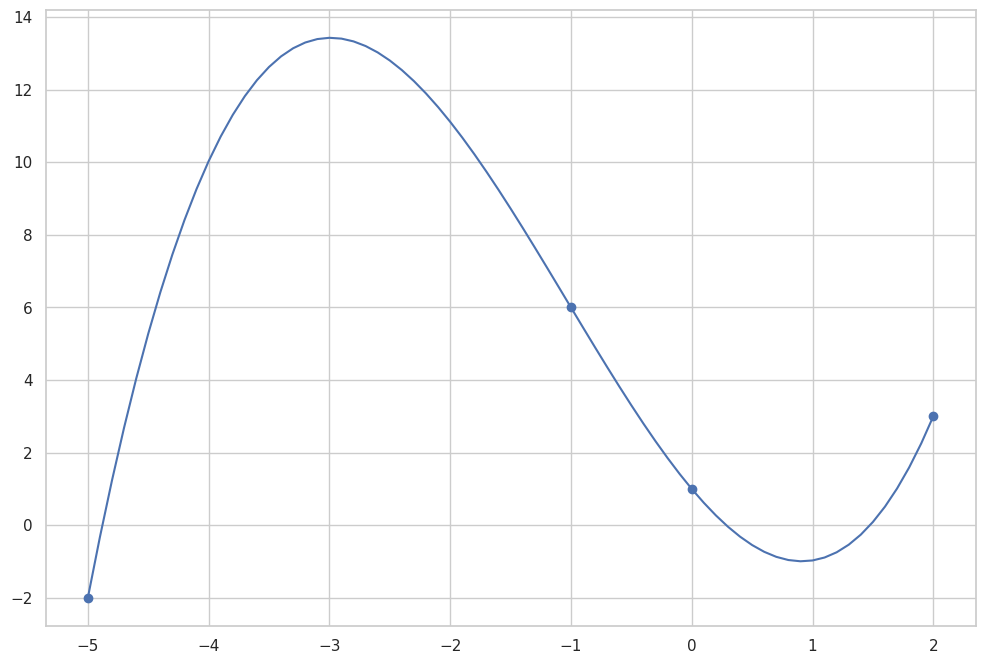

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Import Seaborn

# Instead of using plt.style.use('seaborn-poster'), use Seaborn's set_theme
sns.set_theme(style="whitegrid")  # Or any other Seaborn style you prefer

# Now, any Matplotlib plots created after this will use the Seaborn style

%matplotlib inline
def divided_diff(x, y):
    '''
    function to calculate the divided
    differences table
    '''
    n = len(y)
    coef = np.zeros([n, n])
    # the first column is y
    coef[:,0] = y

    for j in range(1,n):
        for i in range(n-j):
            coef[i][j] = \
           (coef[i+1][j-1] - coef[i][j-1]) / (x[i+j]-x[i])

    return coef

def newton_poly(coef, x_data, x):
    '''
    evaluate the newton polynomial
    at x
    '''
    n = len(x_data) - 1
    p = coef[n]
    for k in range(1,n+1):
        p = coef[n-k] + (x -x_data[n-k])*p
    return p
x = np.array([-5, -1, 0, 2])
y = np.array([-2, 6, 1, 3])
# get the divided difference coef
a_s = divided_diff(x, y)[0, :]

# evaluate on new data points
x_new = np.arange(-5, 2.1, .1)
y_new = newton_poly(a_s, x, x_new)

plt.figure(figsize = (12, 8))
plt.plot(x, y, 'bo')
plt.plot(x_new, y_new)

Fourier Transformations


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-poster')
%matplotlib inline

x = np.linsapce(0, 20, 201)
y = np.sin(x)

plt.figure(figsize = (8, 6))
plt.plot(x, y, 'b')
plt.ylabel('Amplitude')
plt.xlabel('Location(x)')
plt.show()

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

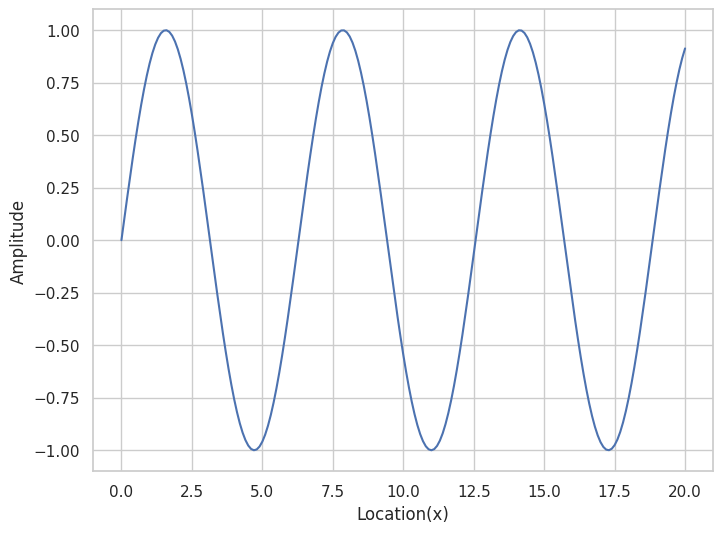

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Use Seaborn's set_theme to apply a style, which will also affect Matplotlib plots.
sns.set_theme(style="whitegrid") # You can choose other Seaborn styles like 'darkgrid', 'ticks', etc.

# %matplotlib inline  # If you are using this in a Jupyter Notebook/IPython environment
x = np.linspace(0, 20, 201)  # Use np.linspace for creating evenly spaced numbers
y = np.sin(x)

plt.figure(figsize = (8, 6))
plt.plot(x, y, 'b')
plt.ylabel('Amplitude')
plt.xlabel('Location(x)')
plt.show()

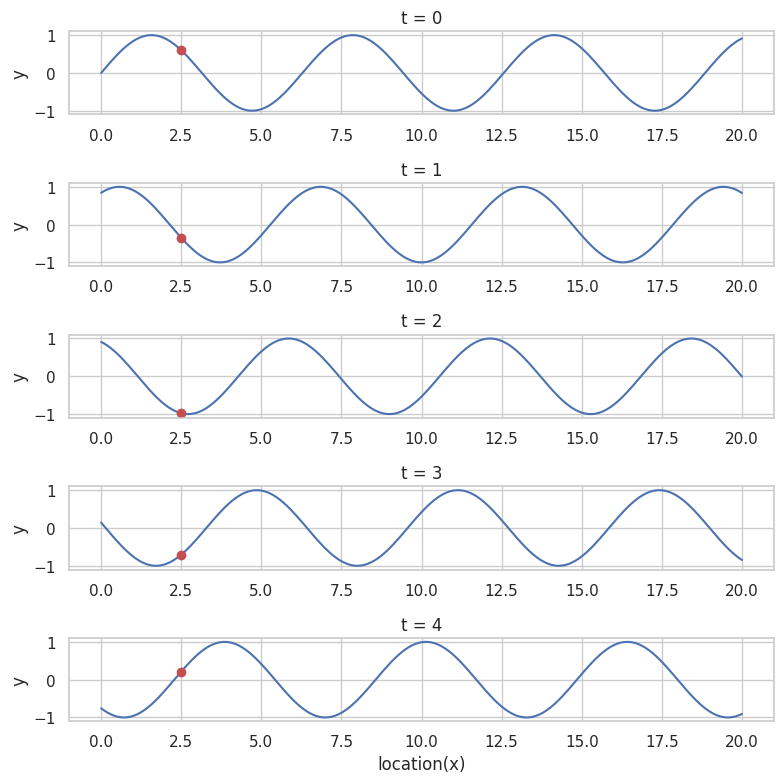

In [ ]:
fig = plt.figure(figsize = (8,8))
times = np.arange(5)

n = len(times)
for t in times:
  plt.subplot(n, 1, t+1)
  y = np.sin(x+t)
  plt.plot(x, y, 'b')
  plt.plot(x[25], y[25], 'ro')
  plt.ylim(-1.1, 1.1)
  plt.ylabel('y')
  plt.title(f't = {t}')
plt.xlabel('location(x)')
plt.tight_layout()
plt.show()


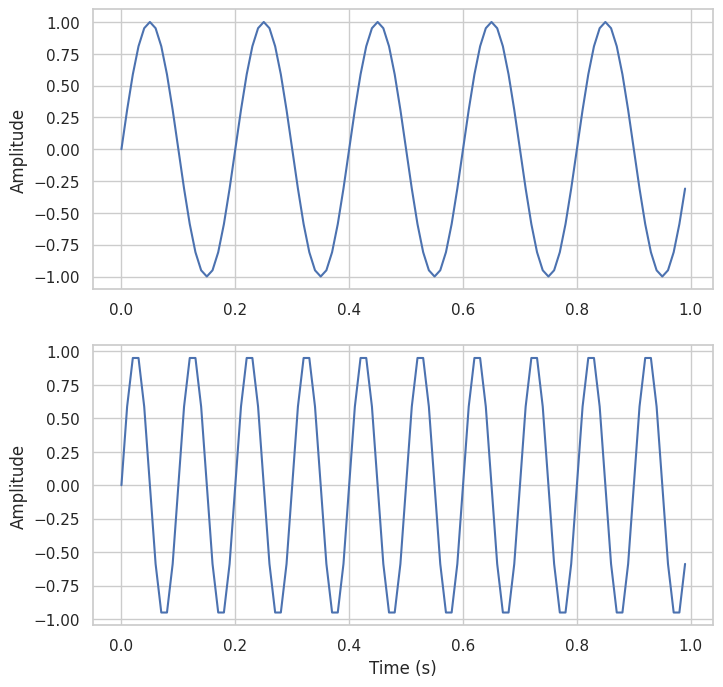

In [ ]:
#sampling rate
sr = 100.0
#sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)
#frequency of the signal
freq = 5
y = np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 8))
plt.subplot(211)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

freq = 10
y = np.sin(2*np.pi*freq*t)

plt.subplot(212)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

plt.xlabel('Time (s)')
plt.show()

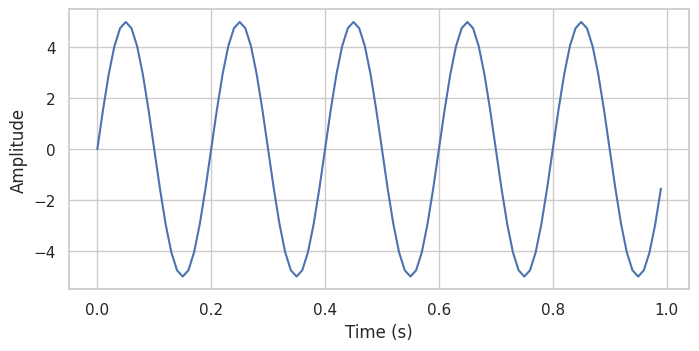

In [ ]:
#frequency of the signal
freq = 5
y = 5*np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 8))
plt.subplot(211)
plt.plot(t, y, 'b')
plt.ylabel('Amplitude')

plt.xlabel('Time (s)')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-poster')
%matplotlib inline

#sampling rate
sr = 100
#sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

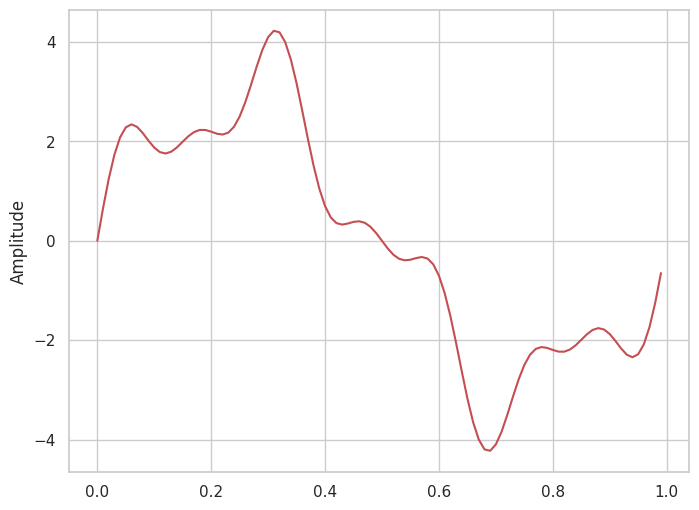

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Make sure seaborn is imported

# Instead of using plt.style.use('seaborn-poster'), use Seaborn's set_theme
sns.set_theme(style="whitegrid")  # Or any other Seaborn style you prefer

# Now, any Matplotlib plots created after this will use the Seaborn style

%matplotlib inline

#sampling rate
sr = 100
#sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

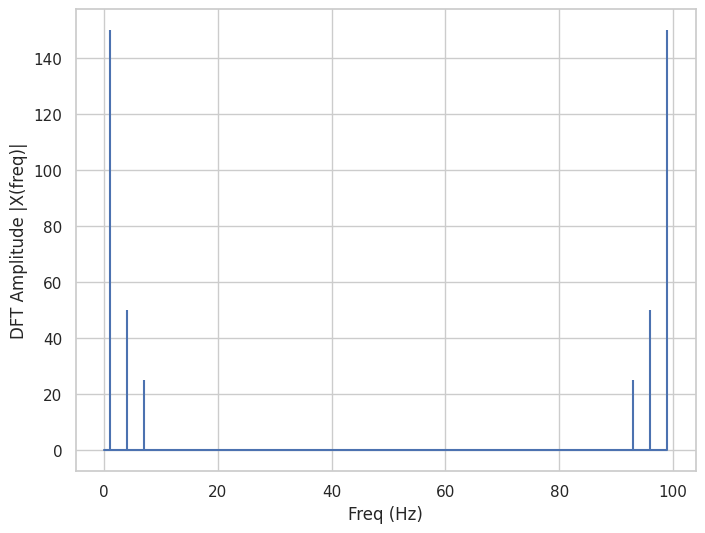

In [ ]:
def DFT(x):
   """
   Function to calculate the
   discrete Fourier Transform
   of a 1D real-valued signal x
   """
   N = len(x)
   n = np.arange(N)
   k = n.reshape((N, 1))
   e = np.exp(-2j * np.pi * k * n / N)

   X = np.dot(e,x)
   return X

X = DFT(x)

#calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T

plt.figure(figsize = (8,6))
plt.stem(freq, abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.show()

In [ ]:
n_oneside = N/2
#get the one side frequency
f_oneside = freq[:n_oneside]

#normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.figure(figsize = (12,6))
plt.subplot(121)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.xlim(0,10)
plt.tight_layout()
plt.show()

TypeError: slice indices must be integers or None or have an __index__ method

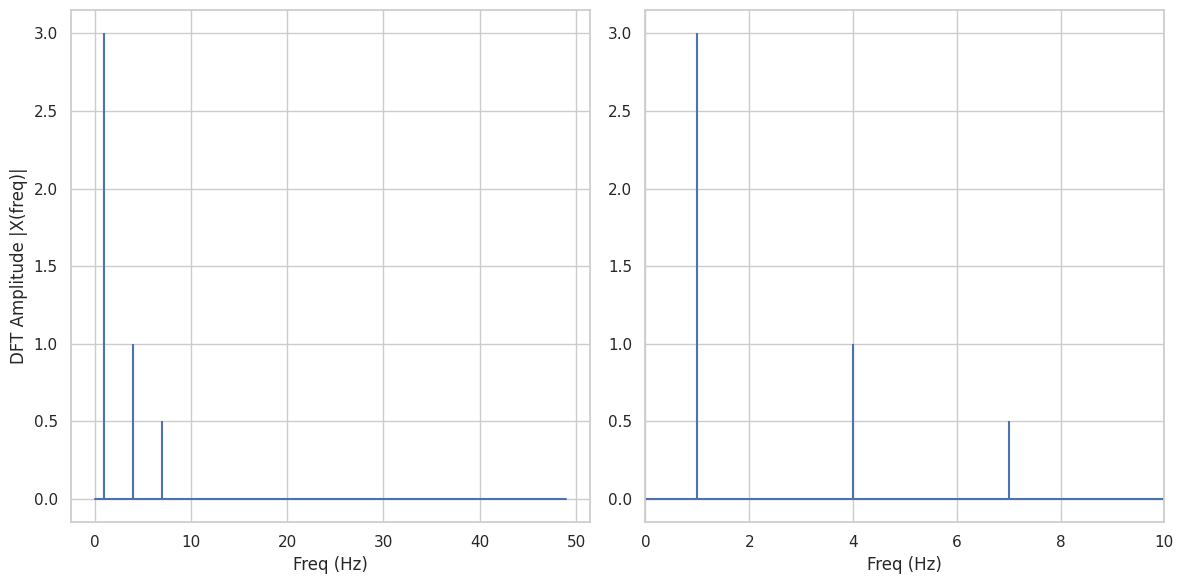

In [ ]:
n_oneside = N // 2  # Use floor division to ensure n_oneside is an integer
#get the one side frequency
f_oneside = freq[:n_oneside]

#normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.figure(figsize = (12,6))
plt.subplot(121)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.xlim(0,10)
plt.tight_layout()
plt.show()

Fast Fourier Transform

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-poster')
%matplotlib inline

def FFT(x):
    """
    A recursive implementation of
    the 1D Cooley-Tukey FFT, the
    input should have a length of
    power of 2.
    """
    N = len(x)

    if N == 1:
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factor = \
          np.exp(-2j*np.pi*np.arange(N)/ N)

        X = np.concatenate(\
            [X_even+factor[:int(N/2)]*X_odd,
             X_even+factor[int(N/2):]*X_odd])
        return X

# sampling rate
sr = 128
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

OSError: 'seaborn-poster' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

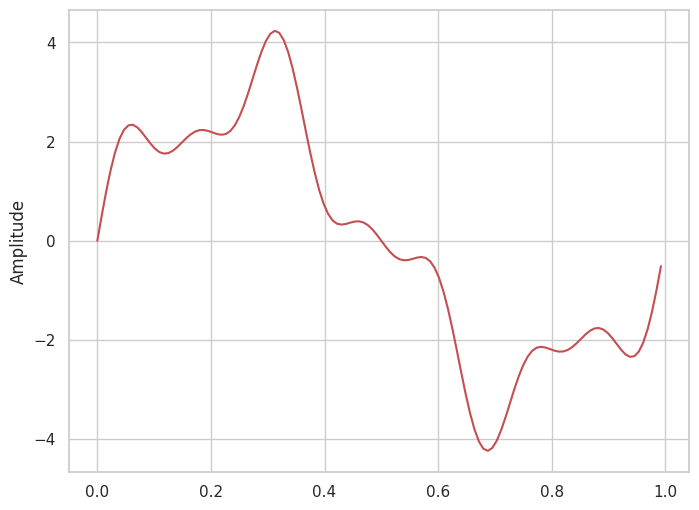

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Make sure seaborn is imported

# Instead of using plt.style.use('seaborn-poster'), use Seaborn's set_theme
sns.set_theme(style="whitegrid")  # Or any other Seaborn style you prefer

# Now, any Matplotlib plots created after this will use the Seaborn style

# %matplotlib inline  # (This line might be needed if you're in a Jupyter Notebook/IPython environment)

def FFT(x):
    """
    A recursive implementation of
    the 1D Cooley-Tukey FFT, the
    input should have a length of
    power of 2.
    """
    N = len(x)

    if N == 1:
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factor = \
          np.exp(-2j*np.pi*np.arange(N)/ N)

        X = np.concatenate(\
            [X_even+factor[:int(N/2)]*X_odd,
             X_even+factor[int(N/2):]*X_odd])
        return X

# sampling rate
sr = 128
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()